In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import mailbox
mboxfile = "/content/All mail Including Spam and Trash.mbox"
mbox = mailbox.mbox(mboxfile)
mbox

In [4]:
if len(mbox) > 0:
  for key in mbox[0].keys():
    print(key)
else:
  print("The mailbox is empty or could not be loaded correctly. Please ensure the 'mboxfile' points to a valid .mbox file after unzipping.")

X-GM-THRID
X-Gmail-Labels
Delivered-To
Received
X-Received
ARC-Seal
ARC-Message-Signature
ARC-Authentication-Results
Return-Path
Received
Received-SPF
Authentication-Results
DKIM-Signature
X-Google-DKIM-Signature
X-Gm-Message-State
MIME-Version
X-Received
Date
X-Account-Notification-Type
Feedback-ID
gmsai
X-Google-Notification-Metadata
X-Notifications
X-Notifications-Bounce-Info
Message-ID
Subject
From
To
Content-Type


In [5]:
import csv

In [6]:
with open('mailbox.csv', 'w') as outputfile:
    writer = csv.writer(outputfile)
    writer.writerow(['subject','from','date','to','label','thread'])
    for message in mbox:
        writer.writerow([
            message['subject'],
            message['from'],
            message['date'],
            message['to'],
            message['X-Gmail-Labels'],
            message['X-GM-THRID']
        ])

In [7]:
dfs = pd.read_csv('mailbox.csv', names=['subject', 'from', 'date', 'to',
'label', 'thread'])

In [8]:
dfs.dtypes

,0
subject,object
from,object
date,object
to,object
label,object
thread,object


In [9]:
dfs['date'] = dfs['date'].apply(lambda x: pd.to_datetime(x,errors='coerce', utc=True))

In [10]:
dfs = dfs[dfs['date'].notna()]

In [11]:
dfs.to_csv('gmail.csv')

In [12]:
dfs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, 1 to 104
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   subject  104 non-null    object             
 1   from     104 non-null    object             
 2   date     104 non-null    datetime64[ns, UTC]
 3   to       104 non-null    object             
 4   label    104 non-null    object             
 5   thread   104 non-null    object             
dtypes: datetime64[ns, UTC](1), object(5)
memory usage: 5.7+ KB


In [13]:
dfs.head(10)

,subject,from,date,to,label,thread
1,Archive of Google data requested,Google Takeout <no-reply@accounts.google.com>,2026-07-27 08:21:24+00:00,shivrdxsk6@gmail.com,"Inbox,Category Updates,Unread",1871855469990998864
2,"Er. Shiva, your posts got 12 impressions last ...",LinkedIn <notifications-noreply@linkedin.com>,2026-07-21 07:00:24+00:00,"""Er. Shiva Kumar"" <shivrdxsk6@gmail.com>","Inbox,Category Social,Unread",1871306794451096673
3,=?UTF-8?Q?AI_Won=E2=80=99t_Replace_Great_Leade...,"""Hiteshi Infotech Pvt. Ltd. via LinkedIn""\r\n ...",2026-07-23 10:41:52+00:00,"""Er. Shiva Kumar"" <shivrdxsk6@gmail.com>","Inbox,Category Updates,Unread",1871501922316915686
4,"Mega Latest Walk-In Drive @TCS, HCL, Cognizant...",Career For Freshers via LinkedIn <newsletters-...,2026-07-24 19:16:05+00:00,"""Er. Shiva Kumar"" <shivrdxsk6@gmail.com>","Inbox,Category Updates,Unread",1871624871359525520
5,"Shiva, you are missing job shortlists",Naukri Campus Jobs <recommendationnc@naukri.com>,2026-07-21 07:20:19+00:00,shivrdxsk6@gmail.com,"Inbox,Opened,Category Personal",1871308159324908283
6,Webinar Alert | ESG fundamentals and the BRSR ...,NISM <outreach@nism.ac.in>,2026-07-21 11:59:39+00:00,SHIVA KUMAR <shivrdxsk6@gmail.com>,"Inbox,Category Promotions,Unread",1871325619040870834
7,=?UTF-8?B?SVBPcyBvcGVuIHRvIGFwcGx5IQ==?=,=?UTF-8?B?R3Jvd3c=?= <noreply@groww.in>,2026-07-24 08:47:33+00:00,<shivrdxsk6@gmail.com>,"Inbox,Category Promotions,Unread",1871585322888028469
8,"PurpleBrake861, Welcome to KinkyPeopleMeet",KinkyPeopleMeet <info@flmsecure.com>,2026-07-24 05:17:45+00:00,shivrdx.sk6@gmail.com,"Spam,Category Updates,Unread",1871572123541358989
9,=?UTF-8?B?8J+SrCBWaXZlayBLdW1hciBj?=\r\n =?UTF...,"""Vivek on Facebook"" <close_friend_updates@face...",2026-07-24 09:54:14+00:00,Shiva Reddy <shivrdx.sk6@gmail.com>,"Inbox,Category Social,Unread",1871589522144252247
10,=?UTF-8?Q?=E2=80=8B=E2=80=8BCaution:_Beware_of...,"""foundit(Monster) Security Center"" <security@m...",2026-07-24 16:11:21+00:00,shivrdxsk6@gmail.com,"Inbox,Category Promotions,Unread",1871613245652397272


In [14]:
import re

In [15]:
def extract_email_ID(string):
    email = re.findall(r'<(.+?)>', string)
    if not email:
        email = list(filter(lambda y: '@' in y, string.split()))
    return email[0] if email else np.nan

In [16]:
dfs['from'] = dfs['from'].apply(lambda x: extract_email_ID(x))

In [17]:
myemail = 'itsmeskm99@gmail.com'
dfs['label'] = dfs['from'].apply(lambda x: 'sent' if x==myemail else 'inbox')

In [18]:
dfs.drop(columns='to', inplace=True)

In [19]:
print(dfs.columns)

Index(['subject', 'from', 'date', 'label', 'thread'], dtype='object')


In [20]:
dfs.head(10)

,subject,from,date,label,thread
1,Archive of Google data requested,no-reply@accounts.google.com,2026-07-27 08:21:24+00:00,inbox,1871855469990998864
2,"Er. Shiva, your posts got 12 impressions last ...",notifications-noreply@linkedin.com,2026-07-21 07:00:24+00:00,inbox,1871306794451096673
3,=?UTF-8?Q?AI_Won=E2=80=99t_Replace_Great_Leade...,newsletters-noreply@linkedin.com,2026-07-23 10:41:52+00:00,inbox,1871501922316915686
4,"Mega Latest Walk-In Drive @TCS, HCL, Cognizant...",newsletters-noreply@linkedin.com,2026-07-24 19:16:05+00:00,inbox,1871624871359525520
5,"Shiva, you are missing job shortlists",recommendationnc@naukri.com,2026-07-21 07:20:19+00:00,inbox,1871308159324908283
6,Webinar Alert | ESG fundamentals and the BRSR ...,outreach@nism.ac.in,2026-07-21 11:59:39+00:00,inbox,1871325619040870834
7,=?UTF-8?B?SVBPcyBvcGVuIHRvIGFwcGx5IQ==?=,noreply@groww.in,2026-07-24 08:47:33+00:00,inbox,1871585322888028469
8,"PurpleBrake861, Welcome to KinkyPeopleMeet",info@flmsecure.com,2026-07-24 05:17:45+00:00,inbox,1871572123541358989
9,=?UTF-8?B?8J+SrCBWaXZlayBLdW1hciBj?=\r\n =?UTF...,close_friend_updates@facebookmail.com,2026-07-24 09:54:14+00:00,inbox,1871589522144252247
10,=?UTF-8?Q?=E2=80=8B=E2=80=8BCaution:_Beware_of...,security@monsterindia.com,2026-07-24 16:11:21+00:00,inbox,1871613245652397272


In [21]:
import datetime
import pytz
def refactor_timezone(x):
    est = pytz.timezone('US/Eastern')
    return x.astimezone(est)

In [22]:
dfs['date'] = dfs['date'].apply(lambda x: refactor_timezone(x))

In [23]:
dfs['dayofweek'] = dfs['date'].apply(lambda x: x.day_name())
dfs['dayofweek'] = pd.Categorical(dfs['dayofweek'], categories=[
'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday',
'Saturday', 'Sunday'], ordered=True)

In [24]:
dfs['timeofday'] = dfs['date'].apply(lambda x: x.hour + x.minute/60
+ x.second/3600)

In [25]:
dfs['hour'] = dfs['date'].apply(lambda x: x.hour)

In [26]:
dfs['year_int'] = dfs['date'].apply(lambda x: x.year)

In [27]:
dfs['year'] = dfs['date'].apply(lambda x: x.year +x.dayofyear/365.25)

In [28]:
dfs.index = dfs['date']
del dfs['date']

In [29]:
print(dfs.index.min().strftime('%a, %d %b %Y %I:%M %p'))
print(dfs.index.max().strftime('%a, %d %b %Y %I:%M %p'))
print(dfs['label'].value_counts())

Thu, 16 Jul 2026 10:35 AM
Mon, 27 Jul 2026 04:21 AM
label
inbox    104
Name: count, dtype: int64


In [30]:
sent = dfs[dfs['label']=='sent']
received = dfs[dfs['label']=='inbox']

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy import ndimage
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

In [32]:
def plot_todo_vs_year(df, ax, color='C0', s=0.5, title=''):
    ind = np.zeros(len(df), dtype='bool')
    est = pytz.timezone('US/Eastern')
    df[~ind].plot.scatter('year', 'timeofday', s=s, alpha=0.6, ax=ax,
    color=color)
    ax.set_ylim(0, 24)
    ax.yaxis.set_major_locator(MaxNLocator(8))
    ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
    24))), "%H").strftime("%I %p") for ts in ax.get_yticks()]);
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title(title)
    ax.grid(ls=':', color='k')
    return ax

/tmp/ipykernel_3189/3342484110.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/3342484110.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,


<Axes: title={'center': 'Received'}>

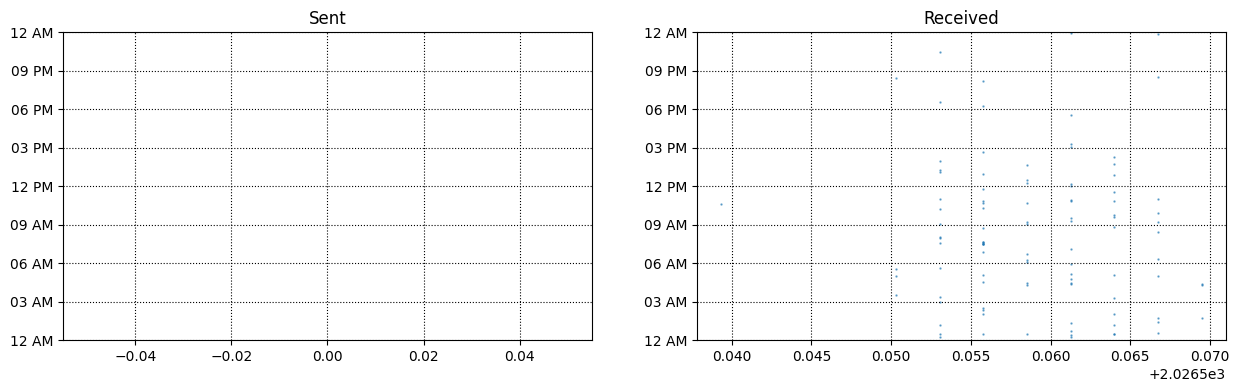

In [33]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 4))
plot_todo_vs_year(sent, ax[0], title='Sent')
plot_todo_vs_year(received, ax[1], title='Received')

In [34]:
def plot_number_perday_per_year(df, ax, label=None, dt=0.3,
                                **plot_kwargs):
    year = df[df['year'].notna()]['year'].values
    if len(year) == 0: # Handle empty dataframe
        return
    T = year.max() - year.min()
    # Ensure bins is at least 1; if T is 0 (all values are identical), one bin is sufficient.
    bins = max(1, int(T / dt)) if T > 0 else 1
    weights = 1 / (np.ones_like(year) * dt * 365.25)
    ax.hist(year, bins=bins, weights=weights, label=label,
            **plot_kwargs);
    ax.grid(ls=':', color='k')

In [35]:
def plot_number_perdhour_per_year(df, ax, label=None, dt=1,
                                  smooth=False,
                                  weight_fun=None, **plot_kwargs):
    tod = df[df['timeofday'].notna()]['timeofday'].values
    year = df[df['year'].notna()]['year'].values
    if len(tod) == 0: # Handle empty dataframe
        return
    Ty = year.max() - year.min()
    T = tod.max() - tod.min()
    # Ensure bins is at least 1; if T is 0 (all values are identical), one bin is sufficient.
    bins = max(1, int(T / dt)) if T > 0 else 1
    if weight_fun is None:
        # Ensure Ty is not zero to avoid division by zero
        if Ty == 0:
            # If Ty is 0, it implies all 'year' values are identical. This might happen
            # if the dataset is very small or all entries are artificially from the exact same 'year' fraction.
            # For simplicity, if Ty is 0, we can set a default, or skip weight calculation if it's not meaningful.
            # Given 'year' is derived from dayofyear, Ty > 0 for non-empty DFs is expected.
            # If it somehow becomes 0, this might indicate an edge case or data issue.
            weights = np.ones_like(tod) # Default to uniform weights if no year range
        else:
            weights = 1 / (np.ones_like(tod) * Ty * 365.25 / dt)
    else:
        weights = weight_fun(df)
    if smooth:
        hst, xedges = np.histogram(tod, bins=bins,
                                   weights=weights);
        x = np.delete(xedges, -1) + 0.5*(xedges[1] - xedges[0])
        hst = ndimage.gaussian_filter(hst, sigma=0.75)
        # Make sure that interp1d is imported from scipy.interpolate
        from scipy.interpolate import interp1d
        f = interp1d(x, hst, kind='cubic')
        x = np.linspace(x.min(), x.max(), 10000)
        hst = f(x)
        ax.plot(x, hst, label=label, **plot_kwargs)
    else:
        ax.hist(tod, bins=bins, weights=weights, label=label,
                **plot_kwargs);
    ax.grid(ls=':', color='k')
    orientation = plot_kwargs.get('orientation')
    if orientation is None or orientation == 'vertical':
        ax.set_xlim(0, 24)
        ax.xaxis.set_major_locator(MaxNLocator(8))
        ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
                                                        24))), "%H").strftime("%I %p")
                            for ts in ax.get_xticks()]);
    elif orientation == 'horizontal':
        ax.set_ylim(0, 24)
        ax.yaxis.set_major_locator(MaxNLocator(8))
        ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,24))), "%H").strftime("%I %p")
                            for ts in ax.get_yticks()]);

In [36]:
class TriplePlot:
    def __init__(self):
        gs = gridspec.GridSpec(6, 6)
        self.ax1 = plt.subplot(gs[2:6, :4])
        self.ax2 = plt.subplot(gs[2:6, 4:6], sharey=self.ax1)
        plt.setp(self.ax2.get_yticklabels(), visible=False);
        self.ax3 = plt.subplot(gs[:2, :4])
        plt.setp(self.ax3.get_xticklabels(), visible=False);

    def plot(self, df, color='darkblue', alpha=0.8, markersize=0.5,
             yr_bin=0.1, hr_bin=0.5):
        plot_todo_vs_year(df, self.ax1, color=color, s=markersize)
        plot_number_perdhour_per_year(df, self.ax2, dt=hr_bin,
                                      color=color, alpha=alpha, orientation='horizontal')
        self.ax2.set_xlabel('Average emails per hour')
        plot_number_perday_per_year(df, self.ax3, dt=yr_bin,
                                    color=color, alpha=alpha)
        self.ax3.set_ylabel('Average emails per day')

/tmp/ipykernel_3189/3342484110.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/4186011230.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,24))), "%H").strftime("%I %p")
/tmp/ipykernel_3189/3342484110.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([datetime.datetime.strptime(str(int(np.mod(ts,


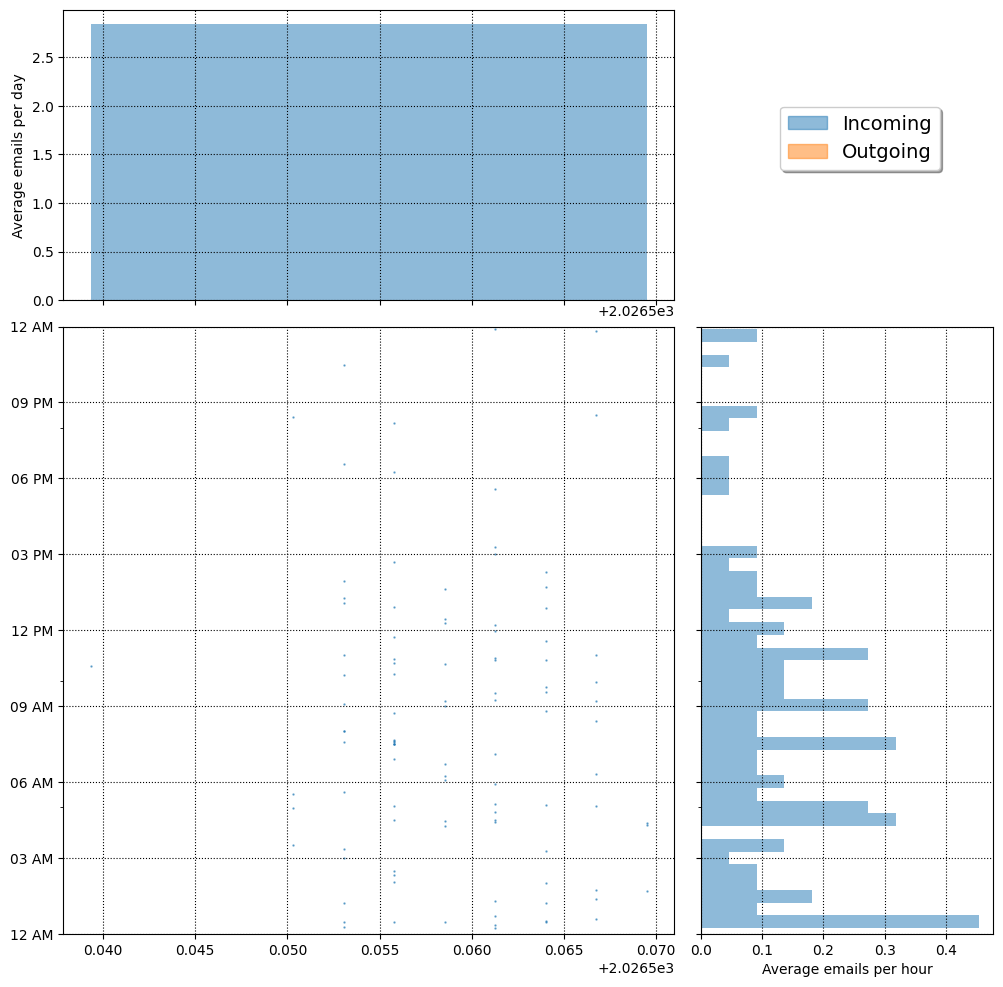

In [37]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
plt.figure(figsize=(12,12));
tpl = TriplePlot()
tpl.plot(received, color='C0', alpha=0.5)
tpl.plot(sent, color='C1', alpha=0.5)
p1 = mpatches.Patch(color='C0', label='Incoming', alpha=0.5)
p2 = mpatches.Patch(color='C1', label='Outgoing', alpha=0.5)
plt.legend(handles=[p1, p2], bbox_to_anchor=[1.45, 0.7],
fontsize=14, shadow=True);

<Axes: xlabel='dayofweek'>

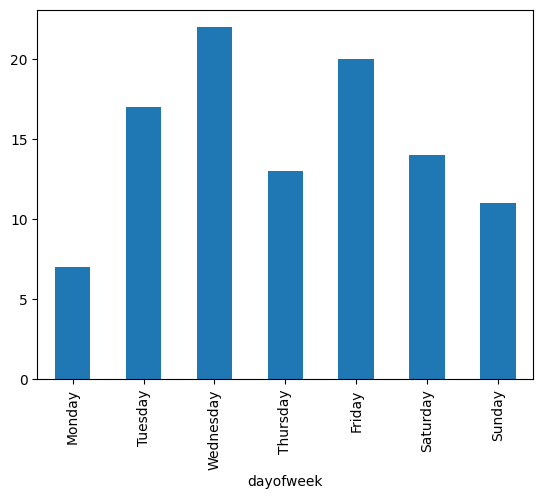

In [38]:
counts = dfs.dayofweek.value_counts(sort=False)
counts.plot(kind='bar')

/tmp/ipykernel_3189/4275054935.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sdw = sent.groupby('dayofweek').size() / len(sent)
/tmp/ipykernel_3189/4275054935.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rdw = received.groupby('dayofweek').size() / len(received)


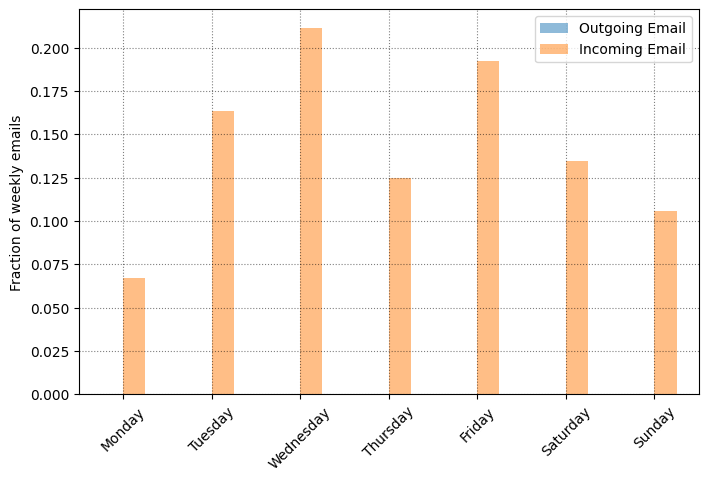

In [39]:
sdw = sent.groupby('dayofweek').size() / len(sent)
rdw = received.groupby('dayofweek').size() / len(received)
df_tmp = pd.DataFrame(data={'Outgoing Email': sdw, 'Incoming Email':rdw})
df_tmp.plot(kind='bar', rot=45, figsize=(8,5), alpha=0.5)
plt.xlabel('');
plt.ylabel('Fraction of weekly emails');
plt.grid(ls=':', color='k', alpha=0.5)

/tmp/ipykernel_3189/4186011230.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/4186011230.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/4186011230.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/4186011230.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([datetime.datetime.strptime(str(int(np.mod(ts,
/tmp/ipykernel_3189/4186011230.py:44: UserWarning: set_ticklabel

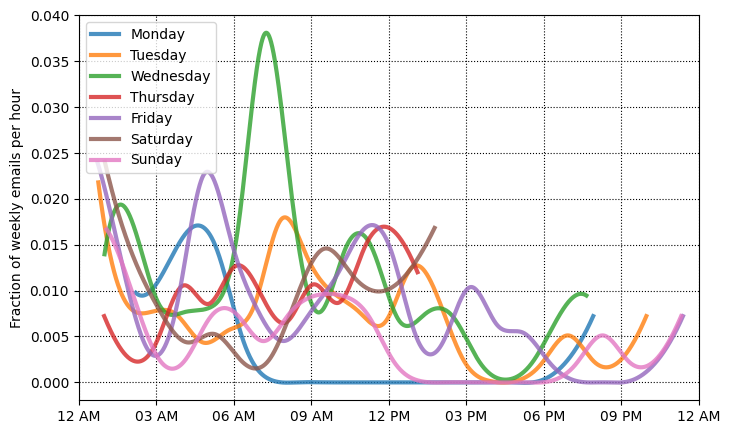

In [40]:
import scipy.ndimage
from scipy.interpolate import interp1d
plt.figure(figsize=(8,5))
ax = plt.subplot(111)
for ct, dow in enumerate(dfs.dayofweek.cat.categories):
    df_r = received[received['dayofweek']==dow]
    weights = np.ones(len(df_r)) / len(received)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(df_r, ax, dt=1, smooth=True,
                                  color=f'C{ct}',
                                  alpha=0.8, lw=3, label=dow, weight_fun=wfun)
    df_s = sent[sent['dayofweek']==dow]
    weights = np.ones(len(df_s)) / len(sent)
    wfun = lambda x: weights
    plot_number_perdhour_per_year(df_s, ax, dt=1, smooth=True,
                                  color=f'C{ct}',
                                  alpha=0.8, lw=2, label=dow, ls='--', weight_fun=wfun)
ax.set_ylabel('Fraction of weekly emails per hour')
plt.legend(loc='upper left')

In [41]:
from wordcloud import WordCloud
df_no_arxiv = dfs[dfs['from'] != 'no-reply@arXiv.org']
text = ' '.join(map(str, received['subject'].values))

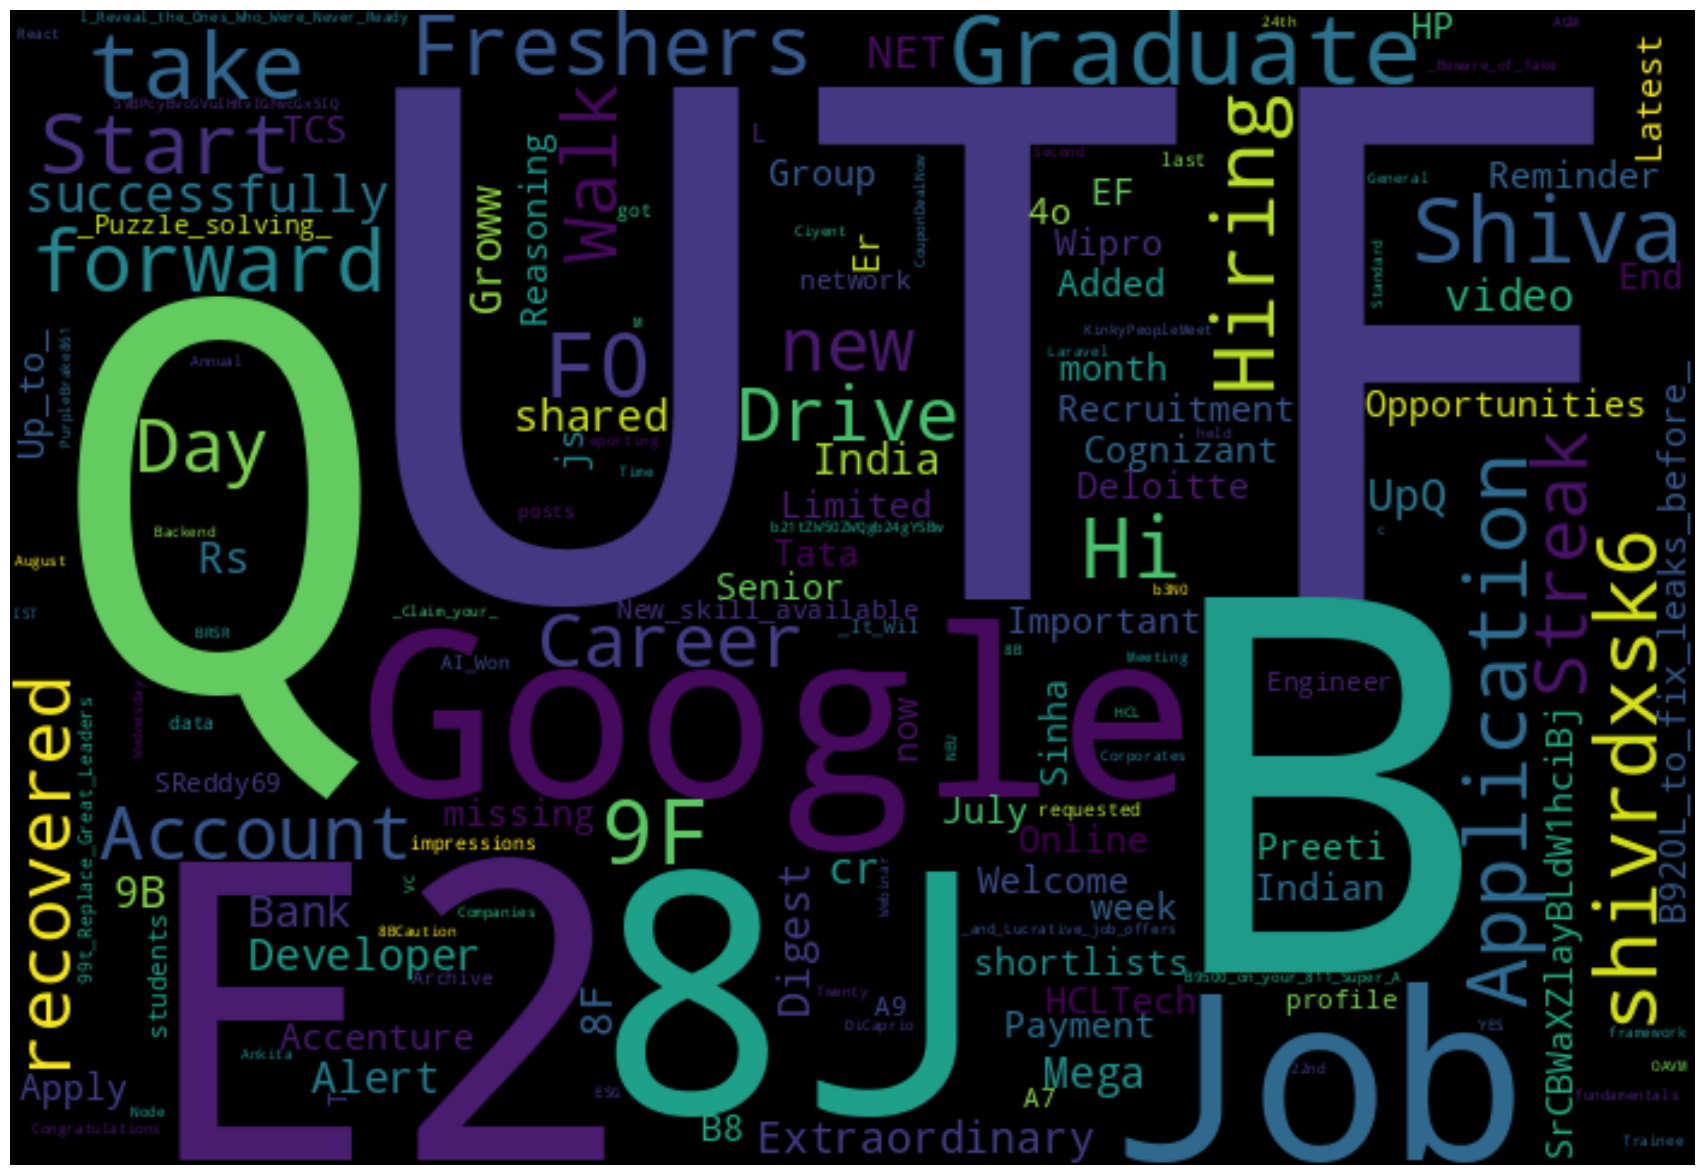

In [42]:
stopwords = ['Re', 'Fwd', '3A_']
wrd = WordCloud(width=700, height=480, margin=0, collocations=False)
for sw in stopwords:
    wrd.stopwords.add(sw)
wordcloud = wrd.generate(text)
plt.figure(figsize=(25,15))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.margins(x=0, y=0)

https://colab.research.google.com/drive/1Zgf_SlwwLc7LJyYagmZJN3BHL78fIFL-?usp=sharing
